# HIHI

## 1. Nạp dữ liệu từ Notebook Tiền xử lý

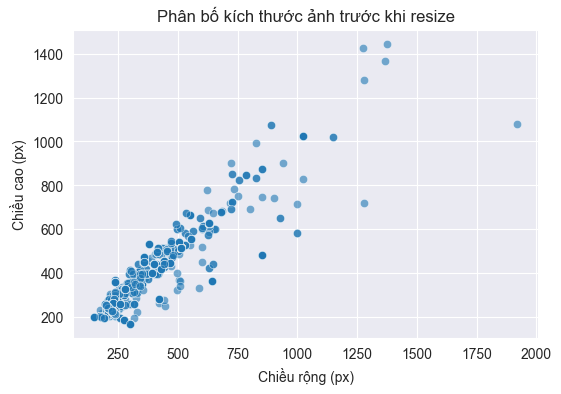

Tổng số ảnh: 7023
Chiều rộng trung bình: 445.9px
Chiều cao trung bình: 448.3px
Training path: D:\NAM BA\Semester 1\ML\Lab\project_ml\data\raw\Training
Testing path: D:\NAM BA\Semester 1\ML\Lab\project_ml\data\raw\Testing

Đang xử lý tập Training...
Bỏ qua Training/glioma (đã có dữ liệu cleaned).
Bỏ qua Training/meningioma (đã có dữ liệu cleaned).
Bỏ qua Training/notumor (đã có dữ liệu cleaned).
Bỏ qua Training/pituitary (đã có dữ liệu cleaned).

Đang xử lý tập Testing...
Bỏ qua Testing/glioma (đã có dữ liệu cleaned).
Bỏ qua Testing/meningioma (đã có dữ liệu cleaned).
Bỏ qua Testing/notumor (đã có dữ liệu cleaned).
Bỏ qua Testing/pituitary (đã có dữ liệu cleaned).

Hoàn tất! Dữ liệu đã được lưu tại:
D:\NAM BA\Semester 1\ML\Lab\project_ml\data\cleaned


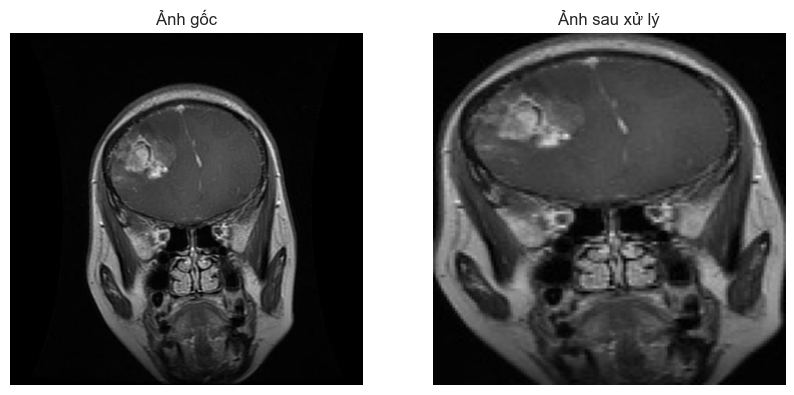

Các lớp tìm thấy: ['glioma', 'meningioma', 'notumor', 'pituitary']
Các lớp tìm thấy: ['glioma', 'meningioma', 'notumor', 'pituitary']

Đọc dữ liệu xong.
Training: (5712, 128, 128, 3) Testing: (1311, 128, 128, 3)
Số lớp: 4
Các nhãn: ['glioma' 'meningioma' 'notumor' 'pituitary']

Thống kê dữ liệu sau chuẩn hoá:
Train set: (5712, 128, 128, 3) (5712,)
Test set: (1311, 128, 128, 3) (1311,)
Giá trị pixel min: 0.0 max: 1.0
Số lớp: 4
Tên lớp: ['glioma' 'meningioma' 'notumor' 'pituitary']


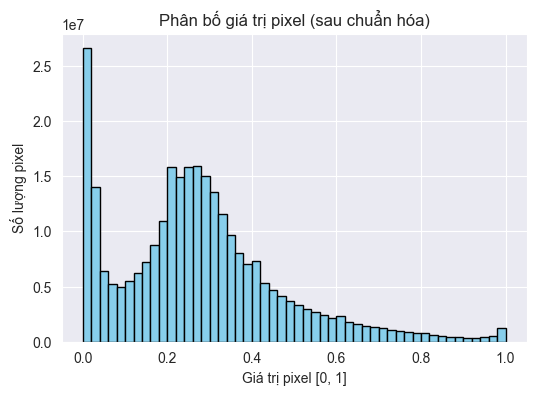

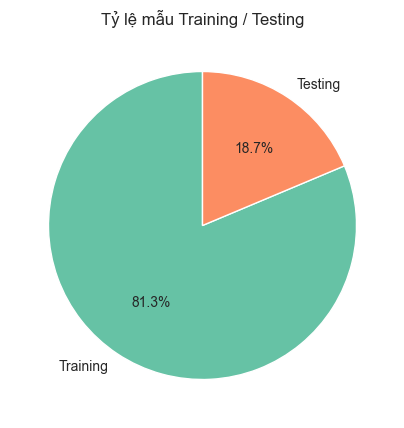

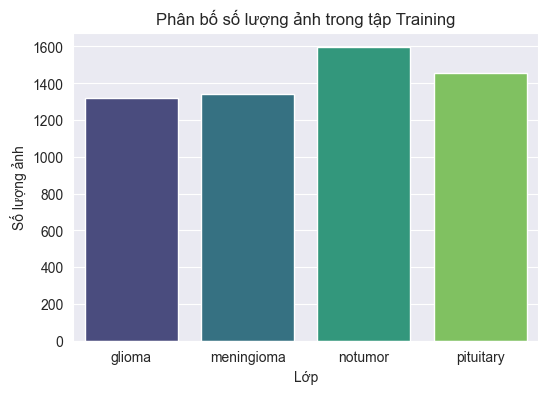

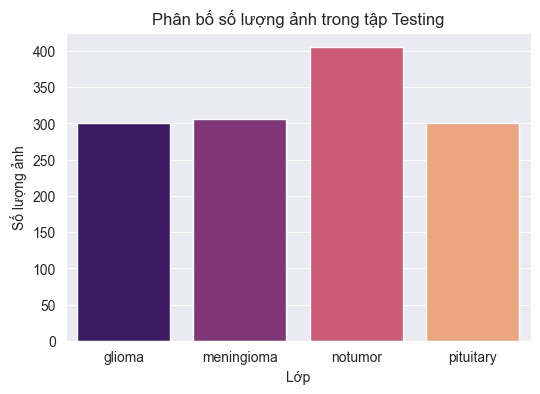

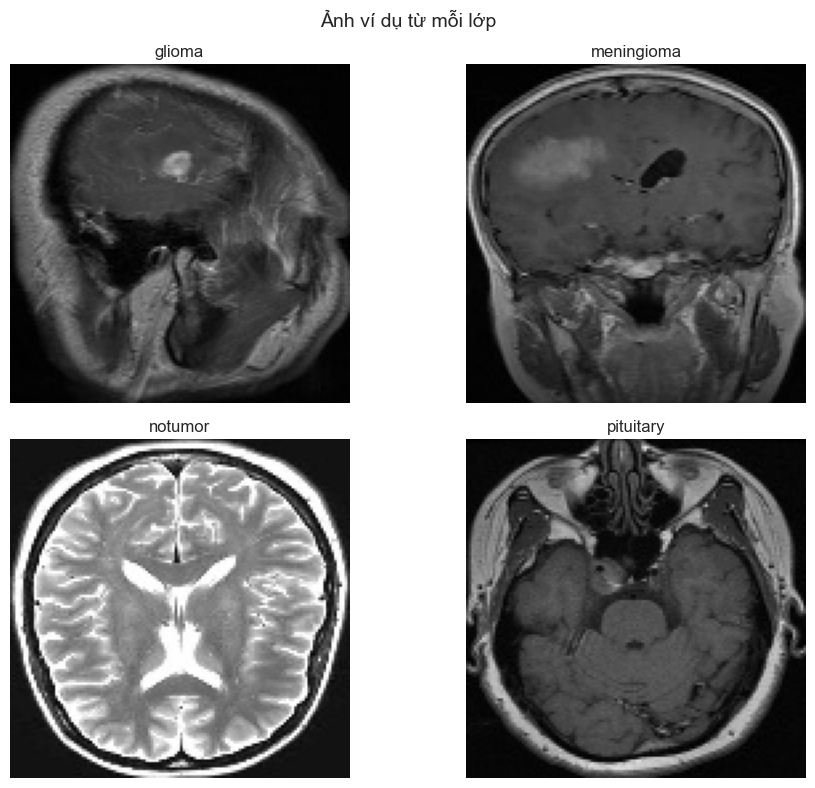


Bắt đầu trích xuất HOG cho tập train...

Bắt đầu trích xuất HOG cho tập test...

Hoàn tất trích xuất HOG.
Kích thước đặc trưng:
X_train_hog: (5712, 8100)
X_test_hog: (1311, 8100)


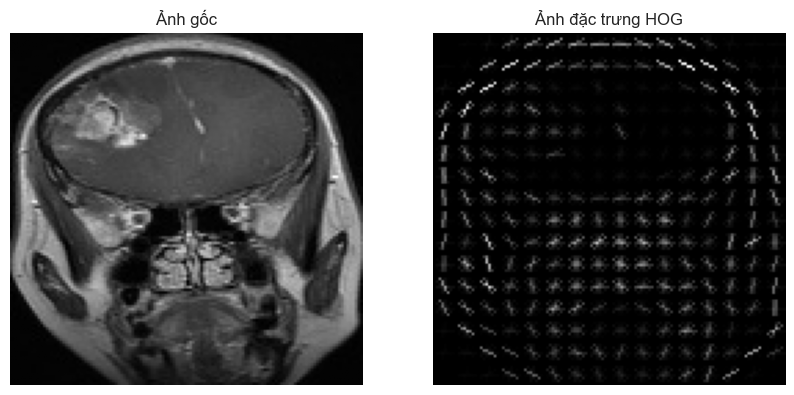

--- Phân tích tập X_train_hog ---
Kích thước dữ liệu: (5712, 8100)
Tổng số đặc trưng: 46267200
Mean HOG feature: 0.1320
Std HOG feature:  0.1018
Min HOG feature:  0.0000
Max HOG feature:  1.0000
--------------------------------
--- Phân tích tập X_test_hog ---
Kích thước dữ liệu: (1311, 8100)
Tổng số đặc trưng: 10619100
Mean HOG feature: 0.1313
Std HOG feature:  0.1026
Min HOG feature:  0.0000
Max HOG feature:  1.0000
--------------------------------


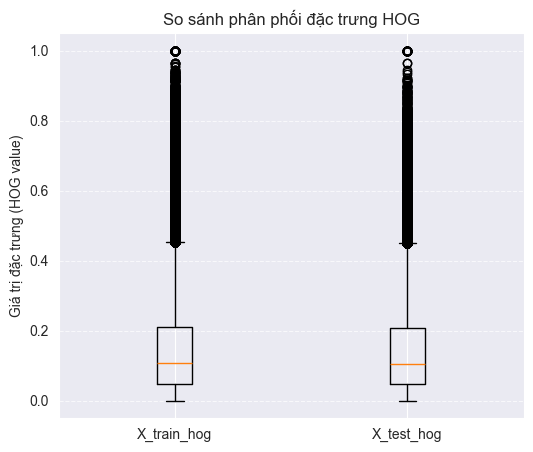

Kích thước X_train sau PCA: (5712, 1213)
Kích thước X_test sau PCA: (1311, 1213)
Explained variance của từng thành phần PC1–PC6: [0.05786734 0.05690109 0.02502863 ... 0.00015202 0.00015181 0.00015153]


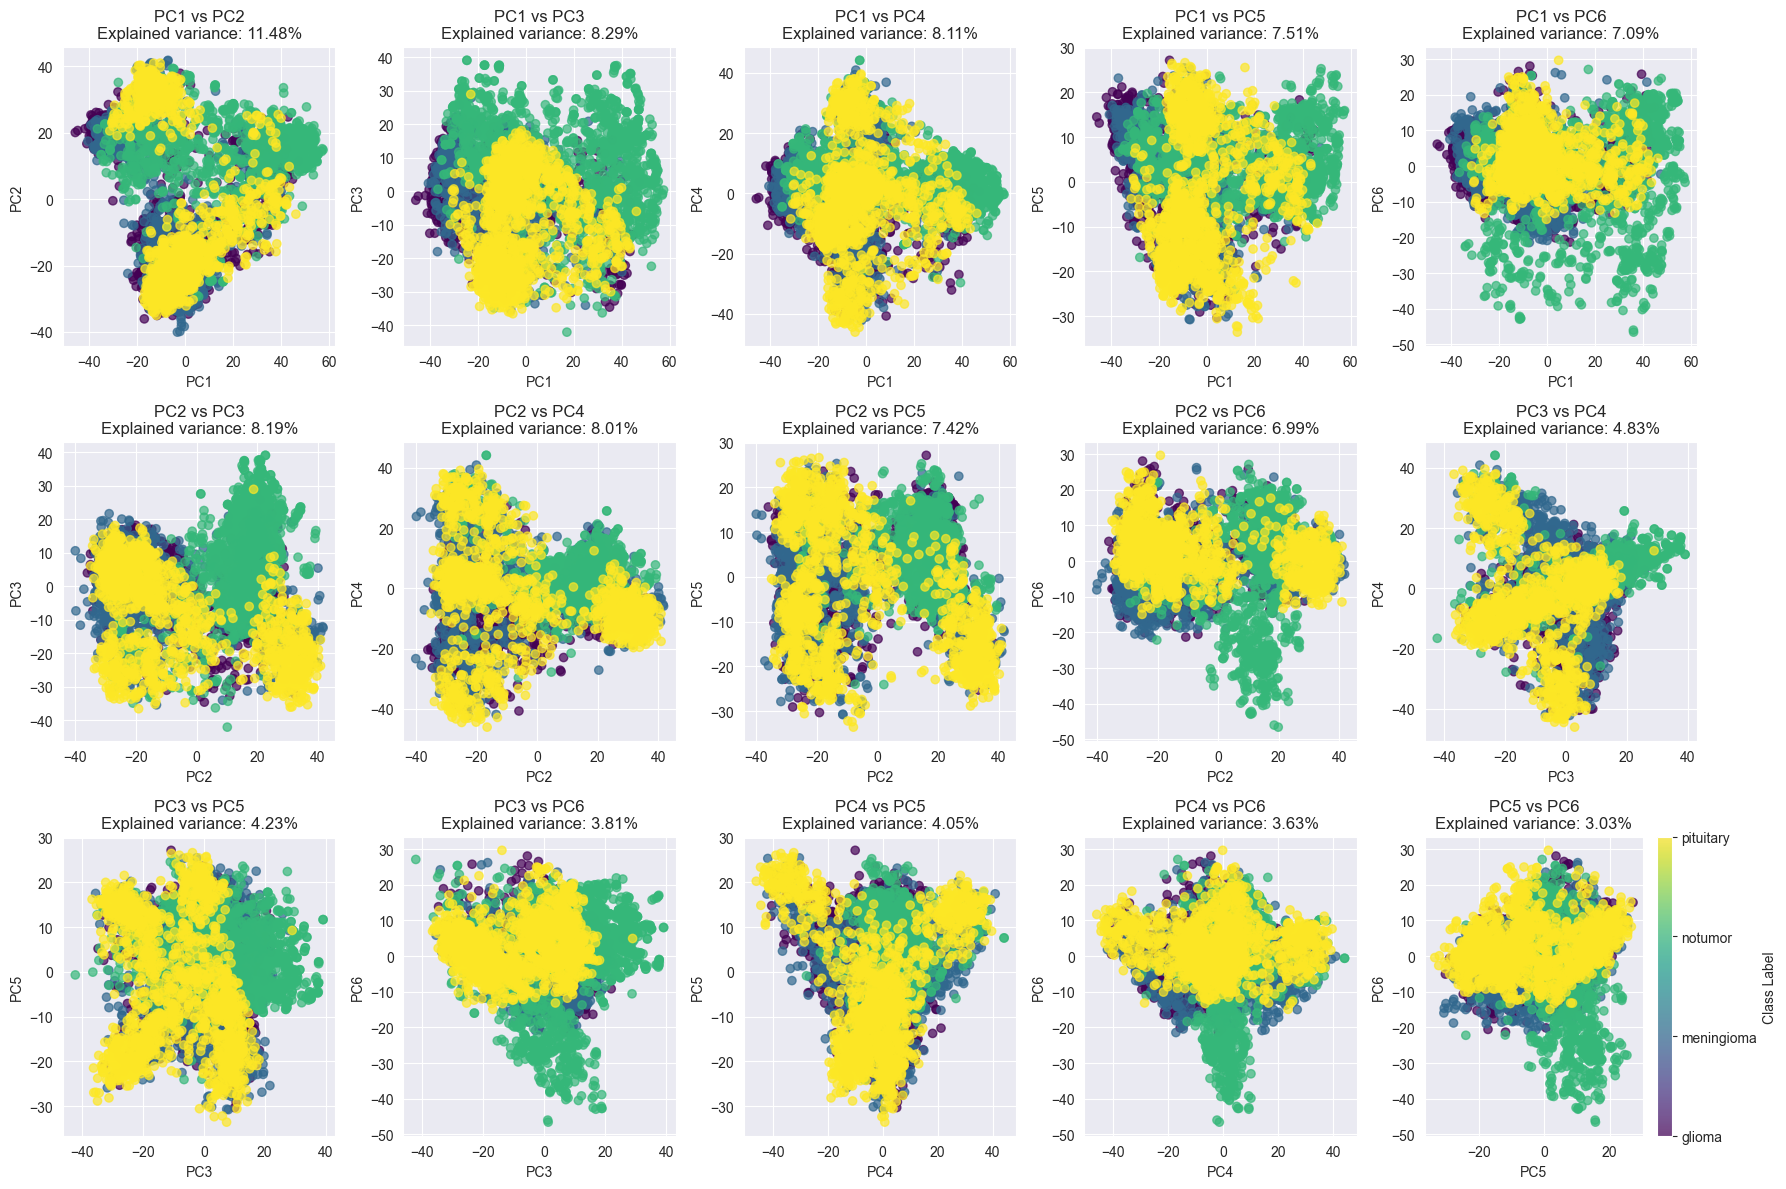

Số thành phần PCA cần để giữ 90% thông tin: 1213


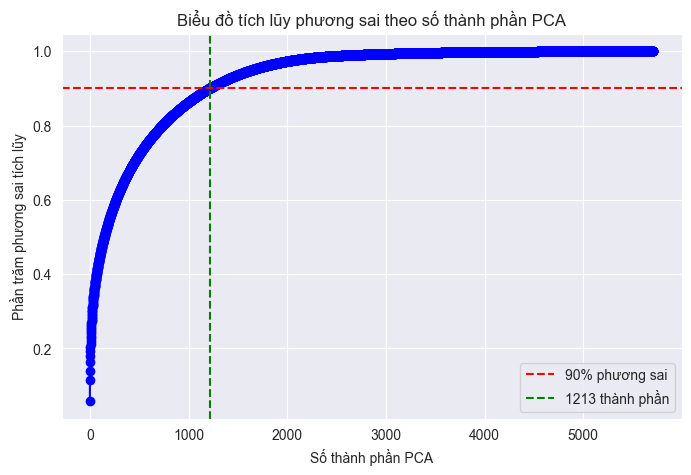

Số lớp của bài toán: 4
Số chiều LDA sẽ giữ lại: 3
Kích thước X_train sau LDA: (5712, 3)
Kích thước X_test sau LDA: (1311, 3)


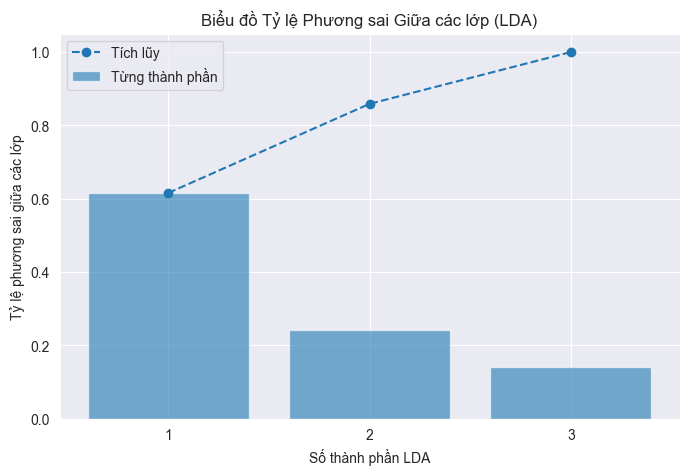

Tỷ lệ phương sai giữa các lớp: [0.61585565 0.24293523 0.14120911]


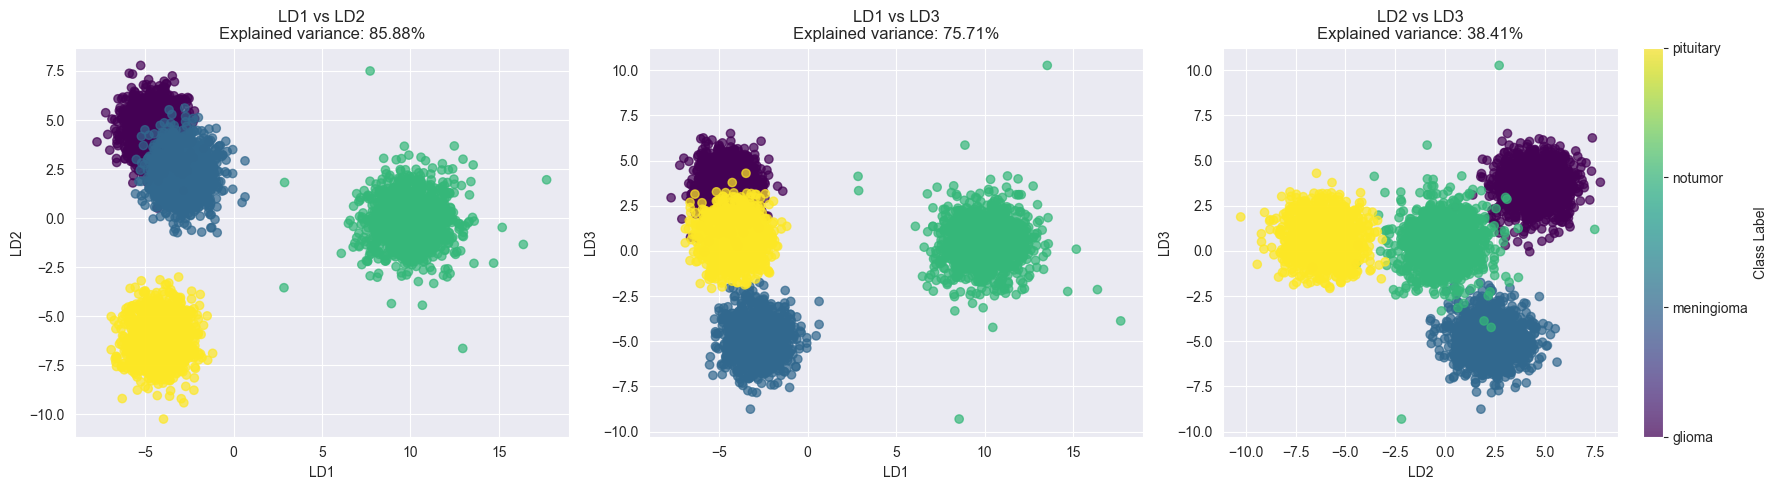

Nhãn: [3 3 3 ... 1 3 0]
Tâm: [[-1.95118698e+01  2.25636992e+01  5.62744455e-02 ...  5.07929468e-04
  -3.40866212e-04 -4.89221911e-03]
 [ 3.35358533e+01  1.18480997e+01  1.59405051e+00 ... -1.30067075e-02
   1.38601535e-02  5.54682173e-03]
 [-1.43644234e+00 -2.09236409e+01 -1.93180404e+01 ...  9.24790963e-03
  -1.12411828e-02 -4.69971776e-04]
 [-3.68575304e+00 -2.10666663e+01  4.14358676e+00 ...  5.14785240e-03
  -5.28556153e-03  8.79226767e-04]]


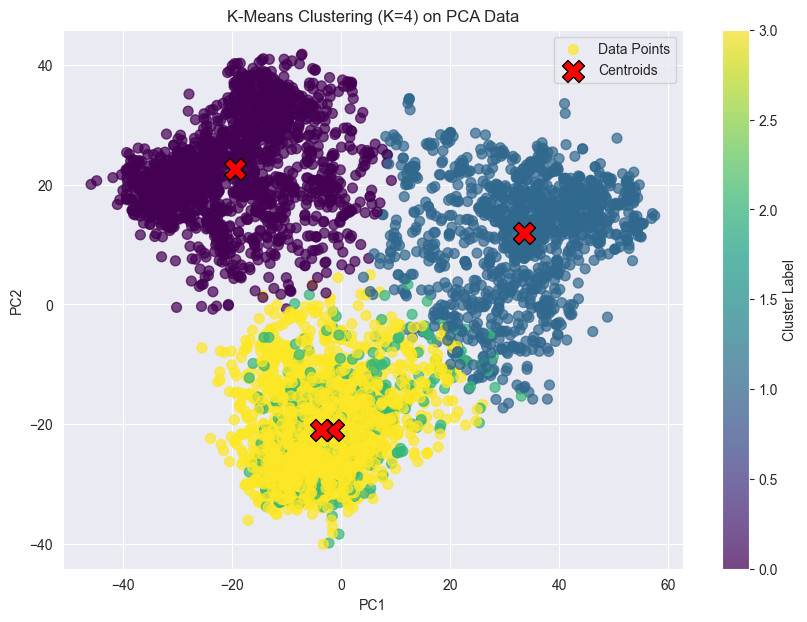

Adjusted Rand Index (ARI - PCA): 0.1319
Normalized Mutual Info (NMI - PCA): 0.1684
V-measure (PCA): 0.1684
Nhãn: [1 1 1 ... 2 2 2]
Tâm: [[ 9.99571444 -0.10132543  0.43922811]
 [-4.48721002  4.49873793  3.64770197]
 [-4.19732531 -6.08360649  0.72961384]
 [-2.89124806  2.30319502 -4.91839386]]


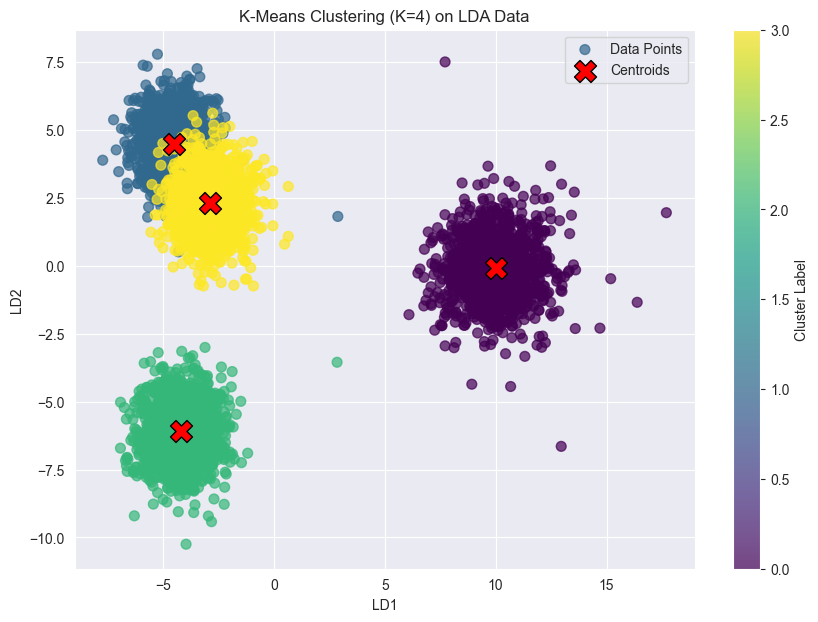

Adjusted Rand Index (ARI - LDA): 0.9990
Normalized Mutual Info (NMI - LDA): 0.9979
V-measure (LDA): 0.9979


In [1]:
# Cell này sẽ thực thi toàn bộ notebook `preprocessing_data.ipynb`.
# Các biến như X_train, y_train_encoded, X_test, y_test_encoded, 
# X_train_hog, X_test_hog, và label_encoder
# sẽ có sẵn trong môi trường của notebook này sau khi chạy xong.

%run preprocessing_data.ipynb

## 2. Import thư viện và thiết lập môi trường

In [7]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings

# Bỏ qua các cảnh báo để output được sạch sẽ hơn
warnings.filterwarnings('ignore')

# --- 1. Định nghĩa các mô hình sẽ sử dụng (Không đổi) ---
models = {
    "Naive Bayes": GaussianNB(var_smoothing=0.5),
    "Logistic Regression (Softmax)": LogisticRegression(
        C=1,
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000
    )
}

# --- 2. Định nghĩa các thí nghiệm dựa trên dữ liệu đã được chia sẵn ---
# Mỗi dictionary chứa tên thí nghiệm và các biến tương ứng
experiments = [
    # --- Dữ liệu HOG gốc ---
    {
        "name": "HOG Gốc - Tỉ lệ 4:1",
        "X_train": X_train_41, "y_train": Y_train_41_pca, # y_train là như nhau cho cả pca và lda
        "X_val": X_val_41, "y_val": Y_val_41_pca
    },
    {
        "name": "HOG Gốc - Tỉ lệ 7:3",
        "X_train": X_train_73, "y_train": Y_train_73_pca,
        "X_val": X_val_73, "y_val": Y_val_73_pca
    },
    {
        "name": "HOG Gốc - Tỉ lệ 6:4",
        "X_train": X_train_64, "y_train": Y_train_64_pca,
        "X_val": X_val_64, "y_val": Y_val_64_pca
    },
    # --- Dữ liệu sau PCA ---
    {
        "name": "Sau PCA - Tỉ lệ 4:1",
        "X_train": X_train_41_pca, "y_train": Y_train_41_pca,
        "X_val": X_val_41_pca, "y_val": Y_val_41_pca
    },
    {
        "name": "Sau PCA - Tỉ lệ 7:3",
        "X_train": X_train_73_pca, "y_train": Y_train_73_pca,
        "X_val": X_val_73_pca, "y_val": Y_val_73_pca
    },
    {
        "name": "Sau PCA - Tỉ lệ 6:4",
        "X_train": X_train_64_pca, "y_train": Y_train_64_pca,
        "X_val": X_val_64_pca, "y_val": Y_val_64_pca
    },
    # --- Dữ liệu sau LDA ---
    {
        "name": "Sau LDA - Tỉ lệ 4:1",
        "X_train": X_train_41_lda, "y_train": Y_train_41_lda,
        "X_val": X_val_41_lda, "y_val": Y_val_41_lda
    },
    {
        "name": "Sau LDA - Tỉ lệ 7:3",
        "X_train": X_train_73_lda, "y_train": Y_train_73_lda,
        "X_val": X_val_73_lda, "y_val": Y_val_73_lda
    },
    {
        "name": "Sau LDA - Tỉ lệ 6:4",
        "X_train": X_train_64_lda, "y_train": Y_train_64_lda,
        "X_val": X_val_64_lda, "y_val": Y_val_64_lda
    },
]

# --- 3. Chuẩn bị nơi lưu trữ kết quả (Không đổi) ---
results_list = []

print("Các mô hình và cấu hình thí nghiệm đã được thiết lập. Sẵn sàng cho cell tiếp theo.")

Các mô hình và cấu hình thí nghiệm đã được thiết lập. Sẵn sàng cho cell tiếp theo.


## 3. Huấn luyện và đánh giá các mô hình

In [8]:
# Bắt đầu vòng lặp chính để huấn luyện
print("BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ\n" + "="*50)

# Vòng lặp 1: Lặp qua từng thí nghiệm đã định nghĩa
for exp in experiments:
    print(f"\n--- Thí nghiệm: {exp['name']} ---")
    
    # Lấy dữ liệu đã được chia sẵn từ dictionary của thí nghiệm
    X_train_sub, y_train_sub = exp['X_train'], exp['y_train']
    X_val, y_val = exp['X_val'], exp['y_val']

    # Vòng lặp 2: Lặp qua từng mô hình
    for m_name, model in models.items():
        # Huấn luyện mô hình trên tập train_sub
        model.fit(X_train_sub, y_train_sub)

        # Dự đoán trên cả tập train và validation để so sánh
        y_train_pred = model.predict(X_train_sub)
        y_val_pred = model.predict(X_val)

        # Tính toán độ chính xác
        train_accuracy = accuracy_score(y_train_sub, y_train_pred)
        val_accuracy = accuracy_score(y_val, y_val_pred)

        # Lưu kết quả vào danh sách
        results_list.append({
            "Thí nghiệm": exp['name'],
            "Mô hình": m_name,
            "Accuracy (Train)": train_accuracy,
            "Accuracy (Validation)": val_accuracy
        })

        # In kết quả tạm thời ra màn hình
        print(f"    - {m_name}: Acc (Train) = {train_accuracy:.4f}, Acc (Validation) = {val_accuracy:.4f}")

print("\n" + "="*50 + "\nQUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ ĐÃ HOÀN TẤT!")

BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN VÀ ĐÁNH GIÁ

--- Thí nghiệm: HOG Gốc - Tỉ lệ 4:1 ---
    - Naive Bayes: Acc (Train) = 0.3206, Acc (Validation) = 0.2493
    - Logistic Regression (Softmax): Acc (Train) = 0.9733, Acc (Validation) = 0.2581

--- Thí nghiệm: HOG Gốc - Tỉ lệ 7:3 ---
    - Naive Bayes: Acc (Train) = 0.3162, Acc (Validation) = 0.2631
    - Logistic Regression (Softmax): Acc (Train) = 0.9805, Acc (Validation) = 0.2439

--- Thí nghiệm: HOG Gốc - Tỉ lệ 6:4 ---
    - Naive Bayes: Acc (Train) = 0.3919, Acc (Validation) = 0.2499
    - Logistic Regression (Softmax): Acc (Train) = 0.9790, Acc (Validation) = 0.2670

--- Thí nghiệm: Sau PCA - Tỉ lệ 4:1 ---
    - Naive Bayes: Acc (Train) = 0.5141, Acc (Validation) = 0.5074
    - Logistic Regression (Softmax): Acc (Train) = 1.0000, Acc (Validation) = 0.8198

--- Thí nghiệm: Sau PCA - Tỉ lệ 7:3 ---
    - Naive Bayes: Acc (Train) = 0.4605, Acc (Validation) = 0.4510
    - Logistic Regression (Softmax): Acc (Train) = 1.0000, Acc (Validation) = 0

## 4. Tổng hợp kết quả

In [9]:
# Tạo một DataFrame từ danh sách kết quả đã thu thập
results_df = pd.DataFrame(results_list)

# --- Chế độ xem 1: Bảng so sánh hiệu suất chính (chỉ trên tập Validation) ---
# Sử dụng pivot_table để sắp xếp lại dữ liệu một cách trực quan
# *** THAY ĐỔI Ở ĐÂY: Sử dụng 'Thí nghiệm' làm index ***
pivot_df = results_df.pivot_table(
    index='Thí nghiệm',
    columns='Mô hình',
    values='Accuracy (Validation)'
)

# Định dạng lại các số trong bảng để hiển thị 4 chữ số thập phân
formatted_pivot = pivot_df.applymap('{:.4f}'.format)

print("BẢNG 1: SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRÊN TẬP VALIDATION")
print("="*75)
print(formatted_pivot)
print("\n" + "="*75)


# --- Chế độ xem 2: Bảng đầy đủ để phân tích Overfitting (sử dụng sau) ---
# Tính toán độ chênh lệch giữa accuracy của tập train và validation
results_df['Chênh lệch (Train-Val)'] = results_df['Accuracy (Train)'] - results_df['Accuracy (Validation)']

print("\nBẢNG 2: DỮ LIỆU ĐẦY ĐỦ ĐỂ PHÂN TÍCH OVERFITTING")
print("="*75)
# *** THAY ĐỔI Ở ĐÂY: Cập nhật lại danh sách các cột để in ra ***
print(results_df[[
    "Thí nghiệm",
    "Mô hình",
    "Accuracy (Train)",
    "Accuracy (Validation)",
    "Chênh lệch (Train-Val)"
]].to_string())

BẢNG 1: SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH TRÊN TẬP VALIDATION
Mô hình             Logistic Regression (Softmax) Naive Bayes
Thí nghiệm                                                   
HOG Gốc - Tỉ lệ 4:1                        0.2581      0.2493
HOG Gốc - Tỉ lệ 6:4                        0.2670      0.2499
HOG Gốc - Tỉ lệ 7:3                        0.2439      0.2631
Sau LDA - Tỉ lệ 4:1                        0.7253      0.7323
Sau LDA - Tỉ lệ 6:4                        0.6228      0.5269
Sau LDA - Tỉ lệ 7:3                        0.7170      0.7328
Sau PCA - Tỉ lệ 4:1                        0.8198      0.5074
Sau PCA - Tỉ lệ 6:4                        0.8083      0.4945
Sau PCA - Tỉ lệ 7:3                        0.8151      0.4510


BẢNG 2: DỮ LIỆU ĐẦY ĐỦ ĐỂ PHÂN TÍCH OVERFITTING
             Thí nghiệm                        Mô hình  Accuracy (Train)  Accuracy (Validation)  Chênh lệch (Train-Val)
0   HOG Gốc - Tỉ lệ 4:1                    Naive Bayes          0.320639               0.2

## 5. Huấn luyện mô hình và dự đoán bằng toàn bộ dữ liệu

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# --- 1. Sử dụng các bộ dữ liệu đã được tính toán sẵn từ preprocessing ---
print("Sử dụng các bộ dữ liệu Train và Test đã có sẵn...")

# Gộp tất cả các biến dữ liệu đã có vào một dictionary để dễ lặp
# Các biến này tồn tại sau khi chạy Cell 1 (%run preprocessing_data.ipynb)
final_datasets = {
    "HOG Gốc": (X_train_hog, X_test_hog),
    "Sau PCA": (X_train_pca, X_test_pca),
    "Sau LDA": (X_train_lda, X_test_lda)
}

# --- 2. Định nghĩa các mô hình để chạy ---
final_models = {
    "Naive Bayes": GaussianNB(var_smoothing=0.5),
    "Logistic Regression (Softmax)": LogisticRegression(
        C=1,
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000
    )
}

# Chuẩn bị nơi lưu kết quả cuối cùng
final_results_list = []
class_names = label_encoder.classes_

# --- 3. Vòng lặp huấn luyện và đánh giá trên tập Test ---
print("\nBẮT ĐẦU QUÁ TRÌNH ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST")
print("="*60)

for data_name, (X_train, X_test) in final_datasets.items():
    print(f"\n---------- Đang xử lý trên dữ liệu: {data_name} ----------")
    for model_name, model in final_models.items():
        print(f"\n>>>>> Mô hình: {model_name} <<<<<")
        
        # Huấn luyện mô hình trên TOÀN BỘ dữ liệu train tương ứng
        model.fit(X_train, y_train_encoded)
        
        # Dự đoán trên tập test tương ứng
        y_test_pred = model.predict(X_test)
        
        # Tính toán và in kết quả
        accuracy = accuracy_score(y_test_encoded, y_test_pred)
        report = classification_report(y_test_encoded, y_test_pred, target_names=class_names, zero_division=0)
        
        print(f"Độ chính xác tổng thể trên tập Test: {accuracy:.4f}")
        print("Báo cáo phân loại chi tiết:")
        print(report)
        
        # Lưu kết quả vào danh sách
        final_results_list.append({
            "Loại dữ liệu": data_name,
            "Mô hình": model_name,
            "Test Accuracy": accuracy
        })

# --- 4. In bảng tóm tắt kết quả cuối cùng ---
print("\n" + "="*60)
print("BẢNG TÓM TẮT KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST")
print("="*60)

final_results_df = pd.DataFrame(final_results_list)
pivot_final = final_results_df.pivot_table(
    index='Loại dữ liệu',
    columns='Mô hình',
    values='Test Accuracy'
)
print(pivot_final.applymap('{:.4f}'.format))

Sử dụng các bộ dữ liệu Train và Test đã có sẵn...

BẮT ĐẦU QUÁ TRÌNH ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST

---------- Đang xử lý trên dữ liệu: HOG Gốc ----------

>>>>> Mô hình: Naive Bayes <<<<<
Độ chính xác tổng thể trên tập Test: 0.6400
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      glioma       0.46      0.68      0.55       300
  meningioma       0.62      0.26      0.37       306
     notumor       0.81      0.78      0.80       405
   pituitary       0.68      0.80      0.73       300

    accuracy                           0.64      1311
   macro avg       0.64      0.63      0.61      1311
weighted avg       0.66      0.64      0.63      1311


>>>>> Mô hình: Logistic Regression (Softmax) <<<<<
Độ chính xác tổng thể trên tập Test: 0.8619
Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      glioma       0.81      0.75      0.78       300
  meningioma       0.77      0.78      0.77       306
     notumor  